In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [2]:
def projectile_range(v, theta, g, air):
    theta = np.radians(theta)
    range_no_air = (v**2 * np.sin(2*theta)) / g
    range_with_air = range_no_air * np.exp(-air)
    return range_with_air


In [3]:
num_simulations = 1000

velocity = np.random.uniform(10, 100, num_simulations)
angle = np.random.uniform(10, 80, num_simulations)
gravity = np.random.uniform(9.5, 10.5, num_simulations)
air_resistance = np.random.uniform(0.0, 0.1, num_simulations)


In [4]:
ranges = []

for i in range(num_simulations):
    r = projectile_range(
        velocity[i],
        angle[i],
        gravity[i],
        air_resistance[i]
    )
    ranges.append(r)


In [5]:
data = pd.DataFrame({
    "Velocity": velocity,
    "Angle": angle,
    "Gravity": gravity,
    "AirResistance": air_resistance,
    "Range": ranges
})

data.head()


,Velocity,Angle,Gravity,AirResistance,Range
0,84.244421,27.431238,9.521246,0.080578,562.375621
1,33.499381,19.255730,10.298636,0.042422,65.032250
2,84.011218,64.444530,10.460262,0.060829,494.192670
3,95.419362,13.032575,9.625475,0.014373,409.695898
4,27.634278,54.648544,10.280596,0.043170,67.145621


In [6]:
X = data.drop("Range", axis=1)
y = data["Range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor()
}


In [8]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,75.965557,101.853778,0.812902
1,Decision Tree,21.146144,31.295346,0.982337
2,Random Forest,12.178906,18.044185,0.994128
3,Support Vector Regressor,104.323165,156.600776,0.557716
4,KNN Regressor,14.622453,22.738147,0.990676


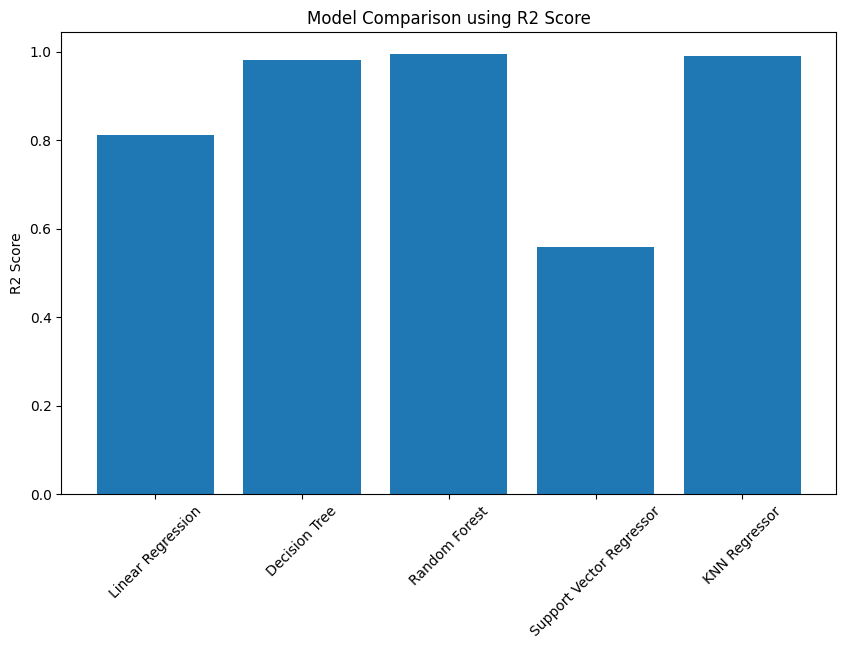

In [9]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison using R2 Score")
plt.ylabel("R2 Score")
plt.show()
